#8.1 Engine lifetime with RNNs

In this exercise, you will develop a Recurrent Neural Network capable of estimating the lifetime of engines. Your final submission should include a link to your google collab notebook, and a pdf adressing the questions asked in the task.

The paper that can help you with the exercises can be found here:\
Wang, Y., Zhao, Y. & Addepalli, S. Practical Options for Adopting Recurrent Neural Network and Its Variants on Remaining Useful Life Prediction. Chin. J. Mech. Eng. 34, 69 (2021). https://doi.org/10.1186/s10033-021-00588-x

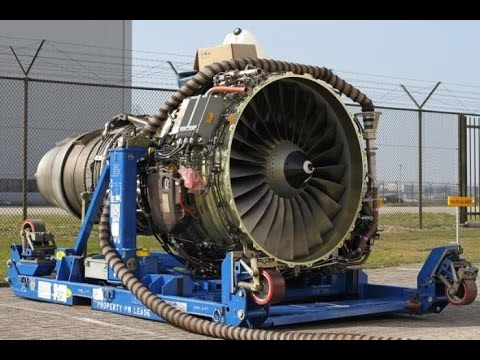



Y. Dwivedi, Predicting Engine Failure using C-MAPSS data, 2018 (https://yajasd.github.io/2018/06/04/Predicting-Engine-Failure/)

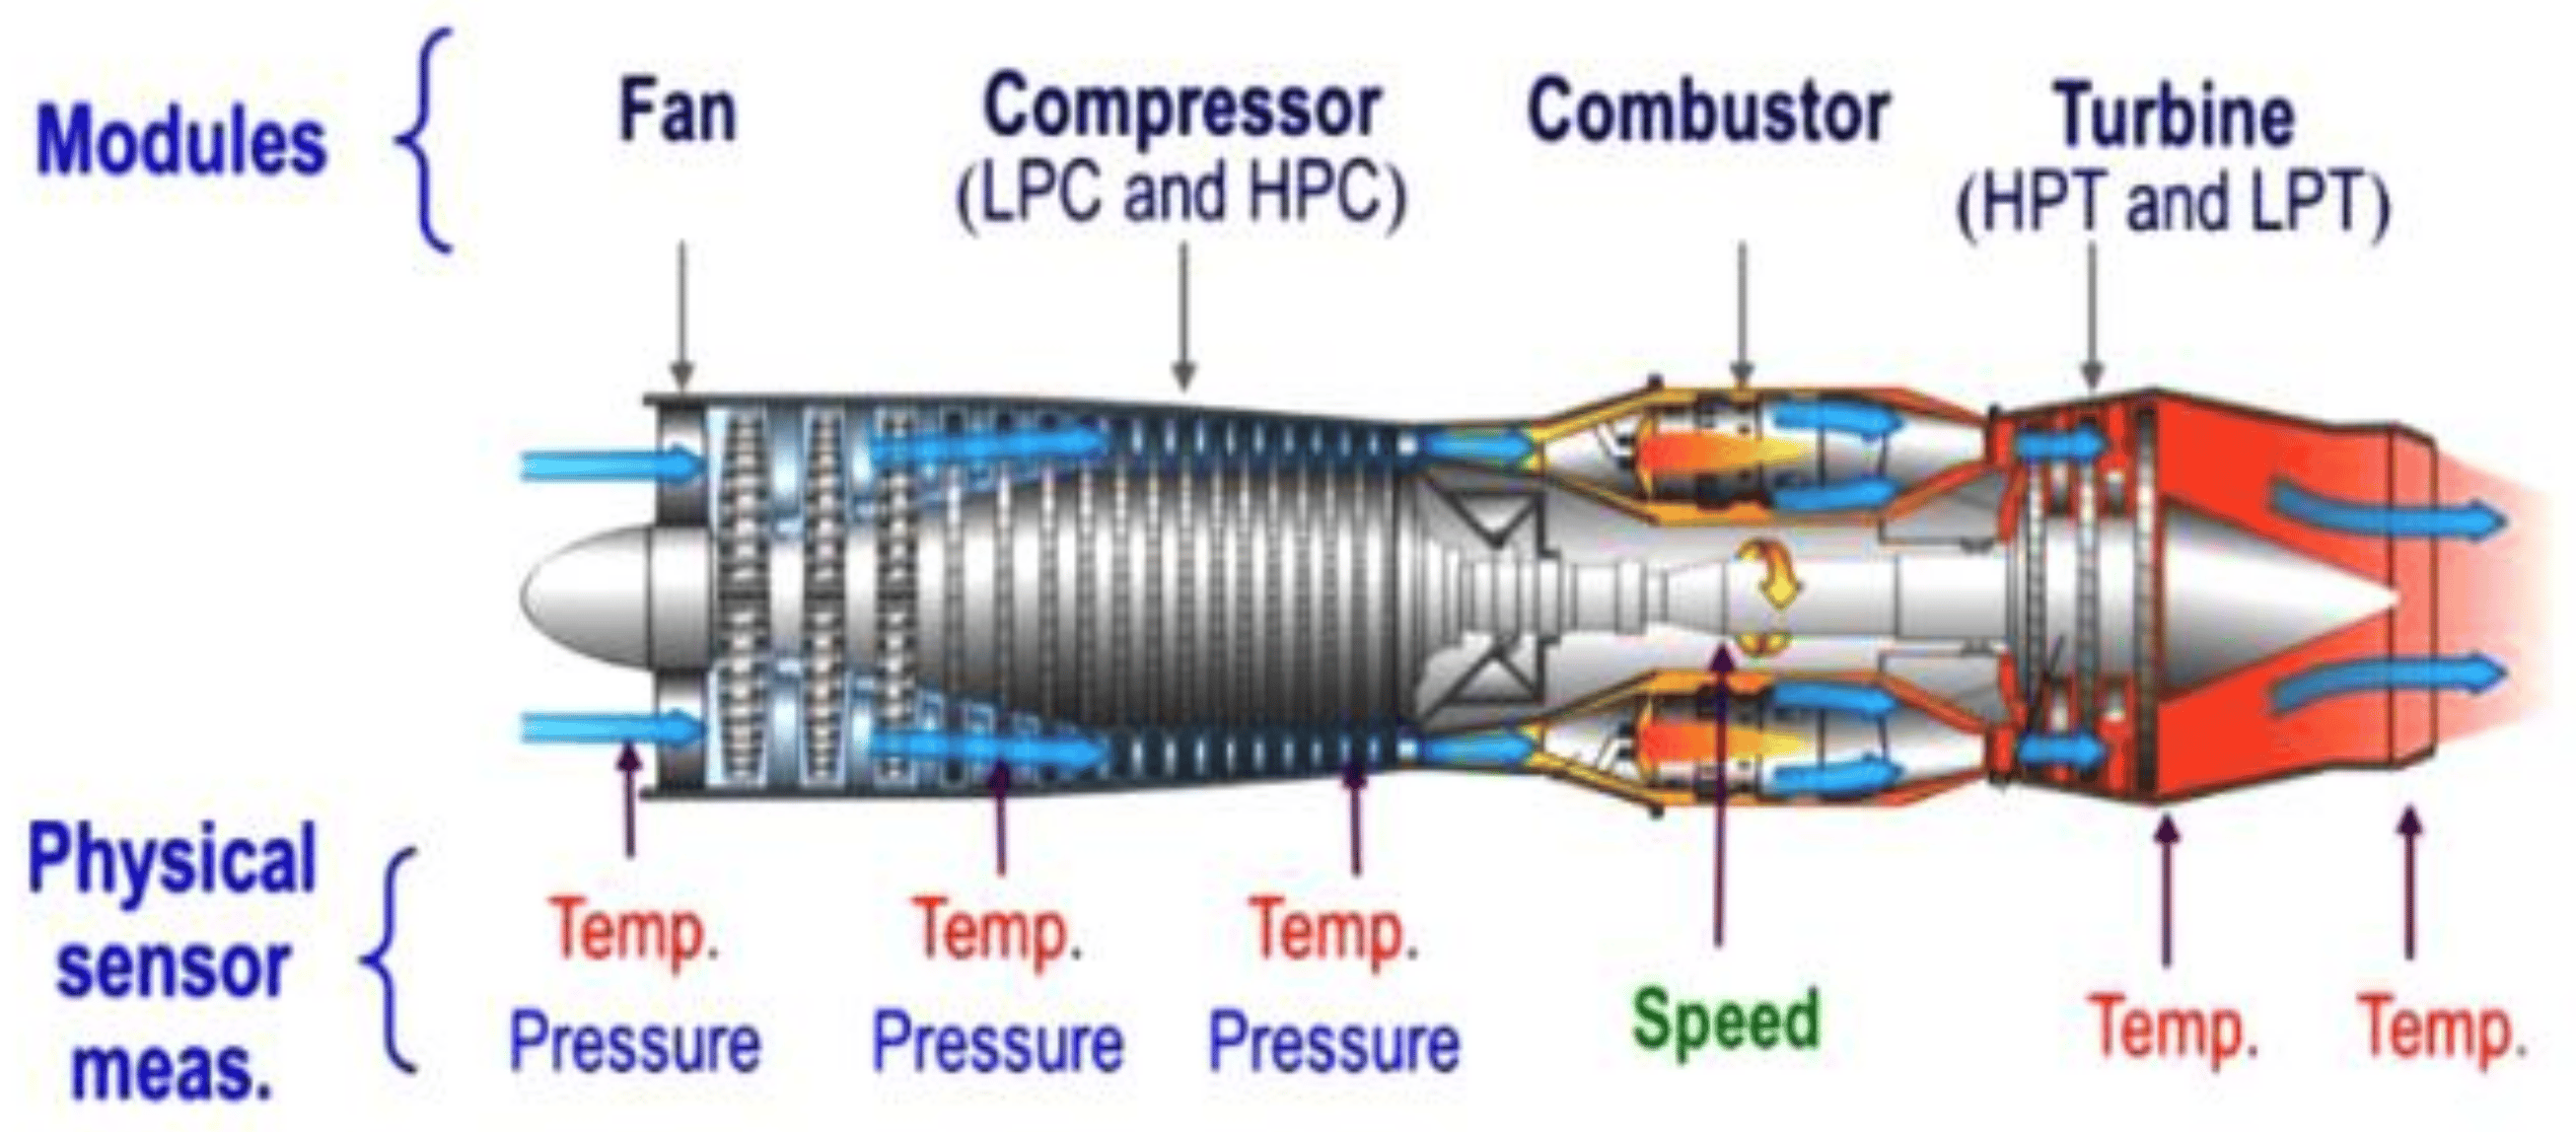


Muneer, A.; Taib, S.M.; Naseer, S.; Ali, R.F.; Aziz, I.A. Data-Driven Deep Learning-Based Attention Mechanism for Remaining Useful Life Prediction: Case Study Application to Turbofan Engine Analysis. Electronics 2021, 10, 2453. https://doi.org/10.3390/electronics10202453

##Experimental Scenario

The goal of this exercise is to develop a model that can predict the remaining lifetime of airplane engines using a recurrent neural network. This exercise shows deep learning apllied to an engineering focused problem where especially the preprocessing of the data is important.

The data consists of multivariate time series of sensor reading and settings from 100 airplane engines, here called *units*. The engines operate normally at the start of each time series, and have been run until they failed. The data is provided in a text file with 26 columns of numbers, separated by spaces. Each column is a different variable and each row represents the setting and sensor values for a given time/cycle, and can hence be seen as a multivariate time series. The columns correspond to:

1\.	unit number\
2\.	time, in cycles\
3\.	operational setting 1\
4\.	operational setting 2\
5\.	operational setting 3\
6\.	sensor measurement  1\
7\.	sensor measurement  2\
... \
26\.	sensor measurement  21

The goal of the exercise is to use an RNN to predict the remaining lifetime of an engine for a certain point in time based on the n_past previous datapoints. The RUL is not given directly in the data files, so we have to calculate it for every time series in the code below. The problem is illustrated in the following figure (showing only one feature):



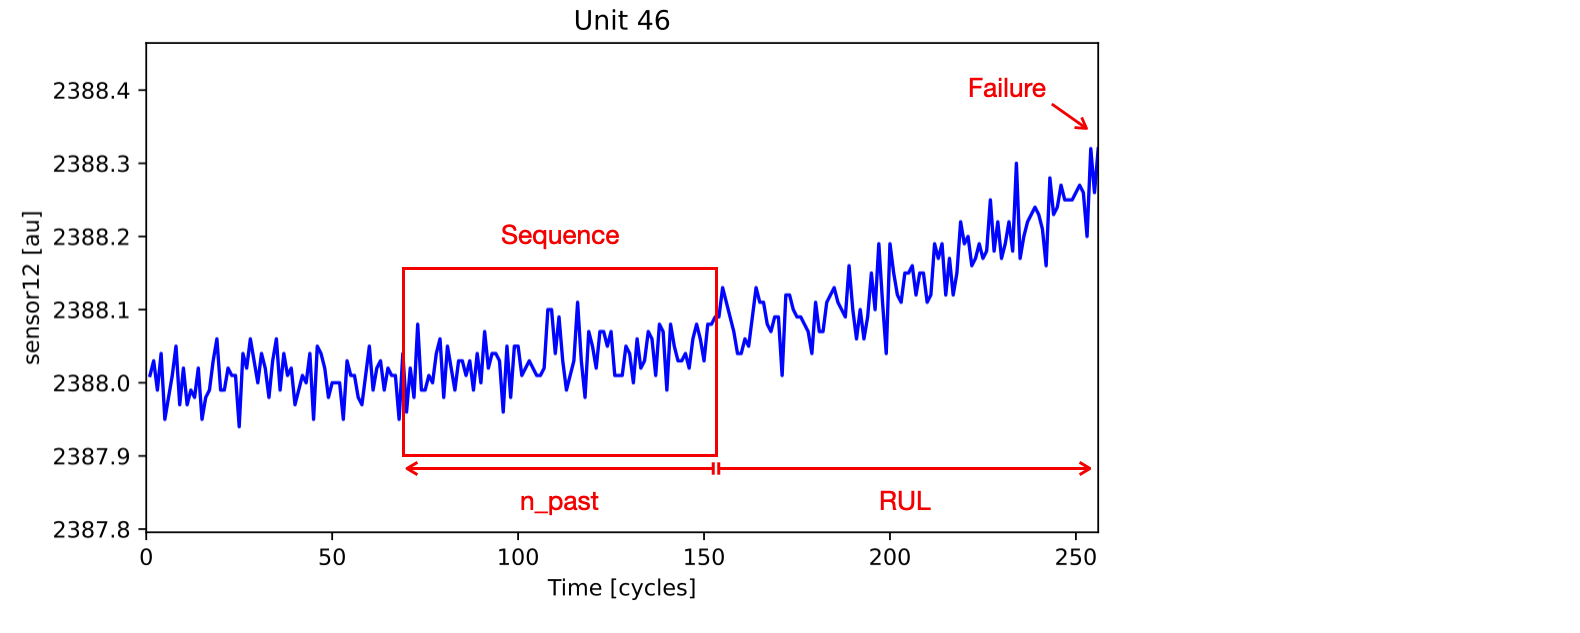

## Tasks


1.   Get familiar with the training data by plotting it for all units and a single unit both before and after normalization.

2.   Run the cell that creates the training data (multivariate time series of length n_past) and calculates the labels (RUL). Describe how the dataprocessing works and plot the RUL for all time steps for all units.

3.   Implement and train a recurrent neural network that predicts the RUL for a multivariate time series of length n_past.

4.   Evaluate the trained model on the training and validation datasets [using MSE and MAE]. What does the final loss mean? Make several plots to evaluate the model, e.g., true vs. prediction, histograms of residuals.

5.   Load and process the test data, which we find in a different file. Evaluate the performance of the model on the processed test data.

6. (optional) If you want to be 95% sure that the engine still has at least 20 cycles to go, at what network output should you recommend maintenance? (The histogram with the residuals can help you with your estimate.)



In [29]:
# You don't have to touch this
import numpy as np
import matplotlib.pyplot as plt
import keras
import pandas as pd
import os
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from tensorflow.keras import callbacks
import tensorflow as tf

layers = keras.layers
models = keras.models

print(keras.__version__)

3.14.1


In [2]:
# This acts as a blindfold. It tells TensorFlow there are exactly 0 GPUs available.
tf.config.set_visible_devices([], 'GPU')

# Optional: Verify it worked (this should print an empty list [])
print("Visible GPUs:", tf.config.get_visible_devices('GPU'))

Visible GPUs: []


## Download the Data

In [3]:
# Download the data set
# You don't have to touch this
if os.path.exists("CMAPSSData.zip") == False:
    !wget https://data.nasa.gov/docs/legacy/CMAPSSData.zip
    !unzip CMAPSSData.zip

## Load the data

In [4]:
# We load the training data (without labels) as a pandas DataFrame. You can read
# the documentation here: https://pandas.pydata.org/docs/reference/frame.html
# You don't have to touch this
data_train = pd.read_csv('CMAPSSData/train_FD001.txt', delimiter=' ', header=None, usecols=range(26))

name_list = ['unit', 'time', 'setting0', 'setting1', 'setting2']

number_of_sensors = 21
for i in range(number_of_sensors):
  name_list.append('sensor'+str(i))

data_train.columns = name_list

## Plot the data for all units

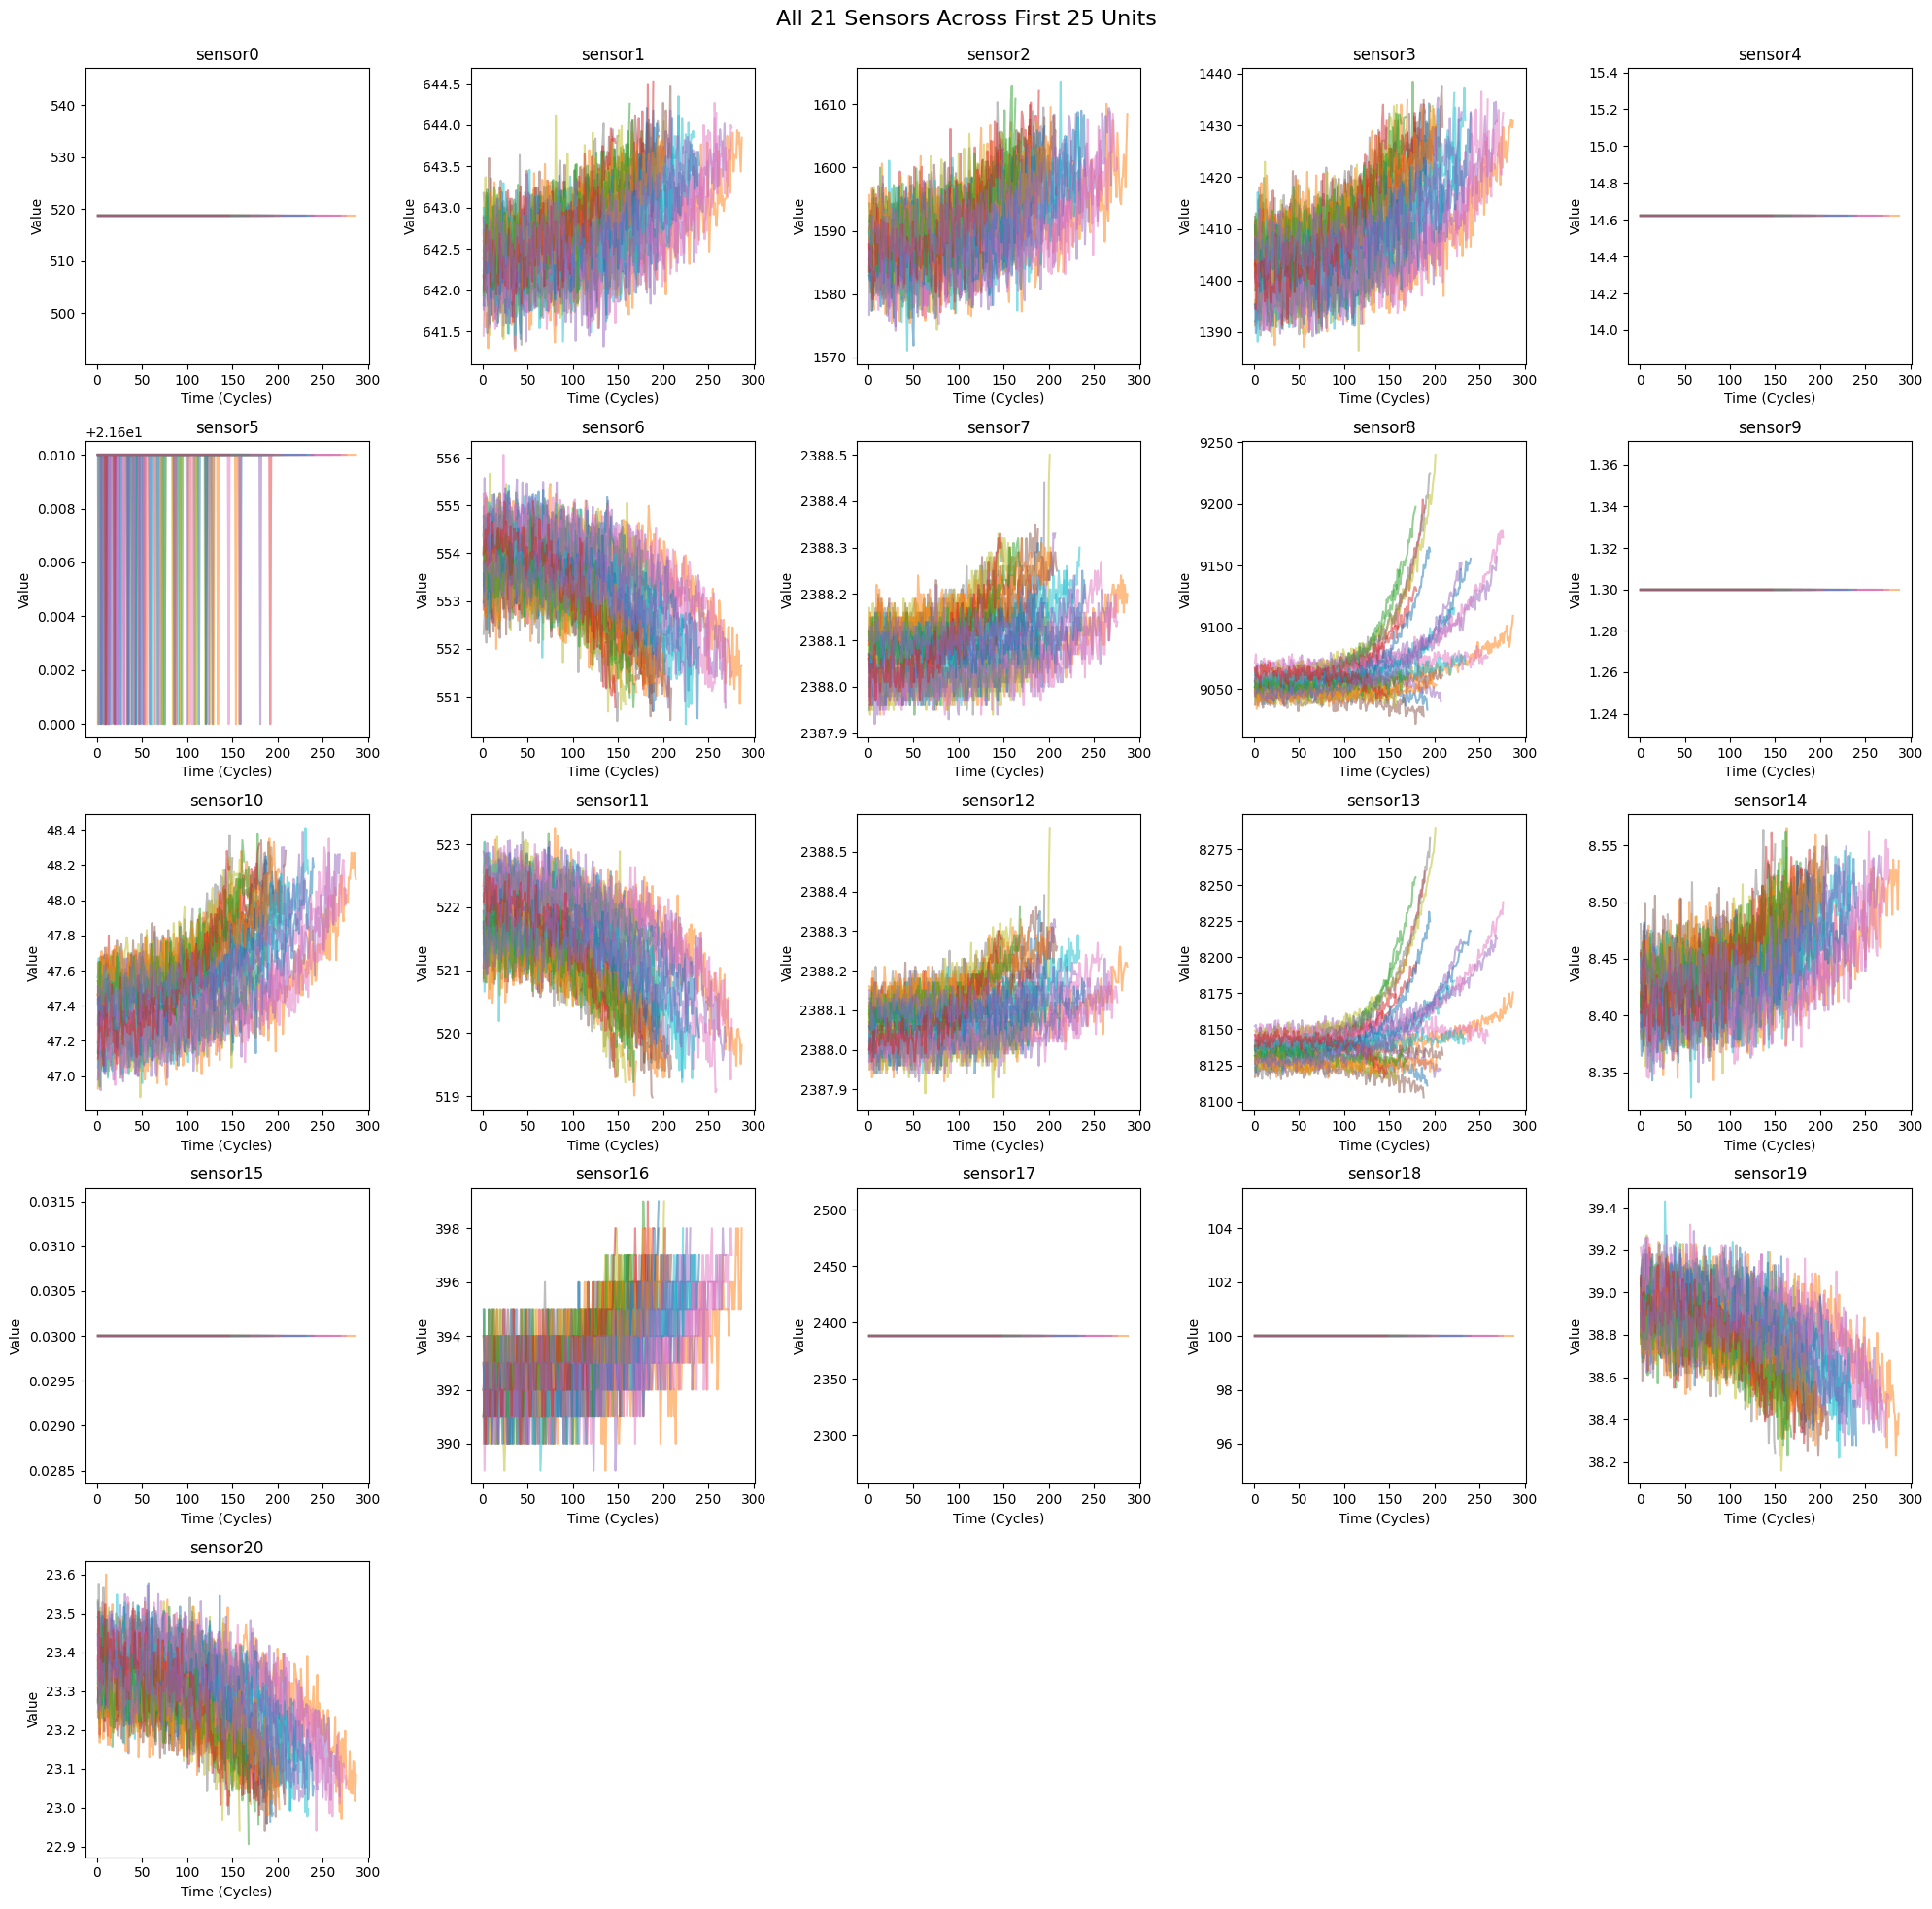

In [5]:
fig, axs = plt.subplots(5, 5, figsize=(20, 20))
fig.suptitle('All 21 Sensors Across First 25 Units', fontsize=16)

# Flatten the axes array for easy iteration
axs = axs.flatten()

#  Loop through all 21 sensors
for i in range(21):
    sensor_name = 'sensor' + str(i)
    
    # Loop through the first 25 units and plot them on the same sensor subplot
    for unit in range(1, 26):
        unit_data = data_train[data_train['unit'] == unit]
        axs[i].plot(unit_data['time'], unit_data[sensor_name], alpha=0.5) # alpha makes lines semi-transparent
        
    axs[i].set_title(sensor_name)
    axs[i].set_xlabel('Time (Cycles)')
    axs[i].set_ylabel('Value')

# Clean up the extra empty subplots (indices 21, 22, 23, 24)
for j in range(21, 25):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

## Plot the data for a single unit

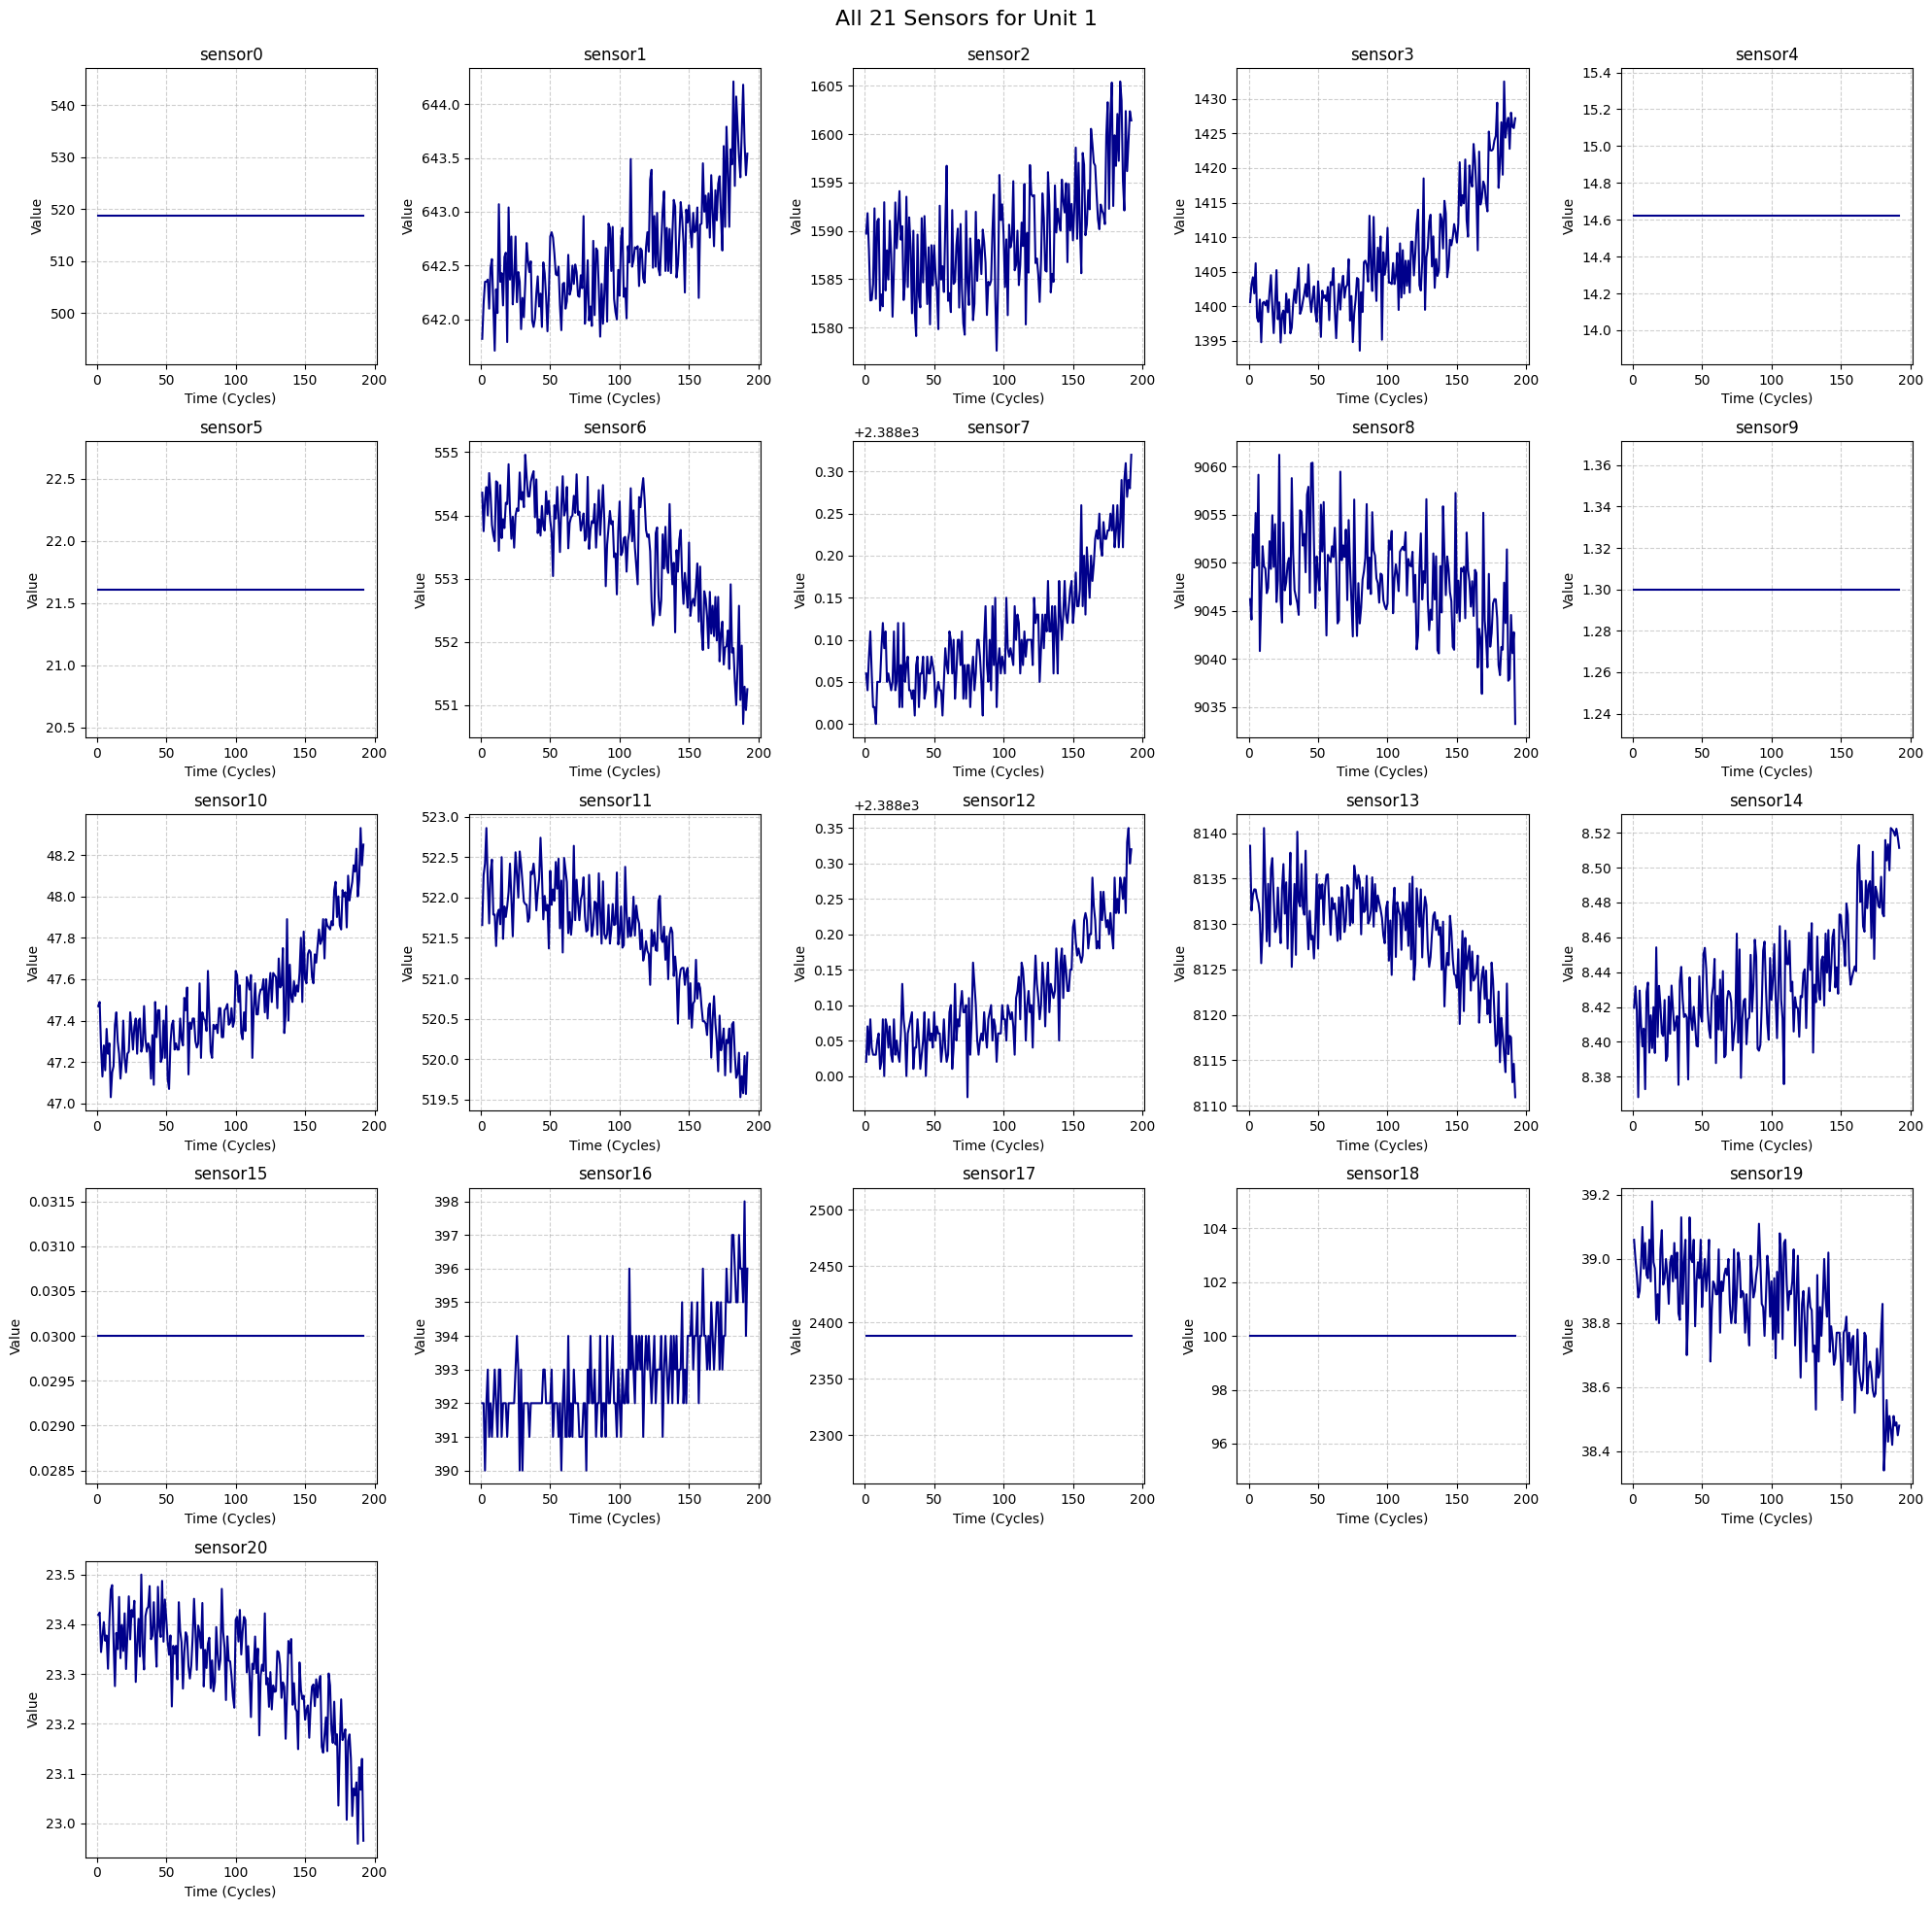

In [6]:
# Plot the input data for a single unit
# Filter for just Unit 1
target_unit = 1
unit_data = data_train[data_train['unit'] == target_unit]

# Setup another 5x5 grid
fig, axs = plt.subplots(5, 5, figsize=(20, 20))
fig.suptitle(f'All 21 Sensors for Unit {target_unit}', fontsize=16)
axs = axs.flatten()

# Plot each sensor for Unit 1
for i in range(21):
    sensor_name = 'sensor' + str(i)
    
    axs[i].plot(unit_data['time'], unit_data[sensor_name], color='darkblue')
    axs[i].set_title(sensor_name)
    axs[i].set_xlabel('Time (Cycles)')
    axs[i].set_ylabel('Value')
    axs[i].grid(True, linestyle='--', alpha=0.6)

# Clean up the empty subplots
for j in range(21, 25):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

## Drop irrelevant columns and normalize the training data

In [7]:
# Choose which columns of data you want to keep and which you want to drop.
# Training with everything works but might not be the best choice.
# Hint 1: Keep "unit" and "time" for now
# Hint 2: Remember to update name_list and n_columns
#...
#data_train = data_train.drop(['xxx'], axis=1)

sensor_cols = [col for col in data_train.columns if 'sensor' in col]
std_devs = data_train[sensor_cols].std()

flat_sensors = std_devs[std_devs < 0.0001].index.tolist()

cols_to_drop = flat_sensors + ['setting0', 'setting1', 'setting2']

data_train = data_train.drop(cols_to_drop, axis=1)
name_list = data_train.columns.tolist()

print(f"Dropped columns: {cols_to_drop}")

Dropped columns: ['sensor0', 'sensor4', 'sensor9', 'sensor15', 'sensor17', 'sensor18', 'setting0', 'setting1', 'setting2']


In [8]:
# Normalization the training data
# Hint: It is a good idea to keep the data as a DataFrame, as the later code will
# assume this format.

data_train_scaled = data_train.copy()

cols_to_normalize = data_train_scaled.columns.difference(['unit', 'time'])
scaler = StandardScaler()
data_train_scaled[cols_to_normalize] = scaler.fit_transform(data_train_scaled[cols_to_normalize])
data_train_scaled.head()

,unit,time,sensor1,sensor2,sensor3,sensor5,sensor6,sensor7,sensor8,sensor10,sensor11,sensor12,sensor13,sensor14,sensor16,sensor19,sensor20
0,1,1,-1.721725,-0.134255,-0.925936,0.141683,1.121141,-0.516338,-0.862813,-0.266467,0.334262,-1.058890,-0.269071,-0.603816,-0.781710,1.348493,1.194427
1,1,2,-1.061780,0.211528,-0.643726,0.141683,0.431930,-0.798093,-0.958818,-0.191583,1.174899,-0.363646,-0.642845,-0.275852,-0.781710,1.016528,1.236922
2,1,3,-0.661813,-0.413166,-0.525953,0.141683,1.008155,-0.234584,-0.557139,-1.015303,1.364721,-0.919841,-0.551629,-0.649144,-2.073094,0.739891,0.503423
3,1,4,-0.661813,-1.261314,-0.784831,0.141683,1.222827,0.188048,-0.713826,-1.539489,1.961302,-0.224597,-0.520176,-1.971665,-0.781710,0.352598,0.777792
4,1,5,-0.621816,-1.251528,-0.301518,0.141683,0.714393,-0.516338,-0.457059,-0.977861,1.052871,-0.780793,-0.521748,-0.339845,-0.136018,0.463253,1.059552


## Plot the normalized training data for all units

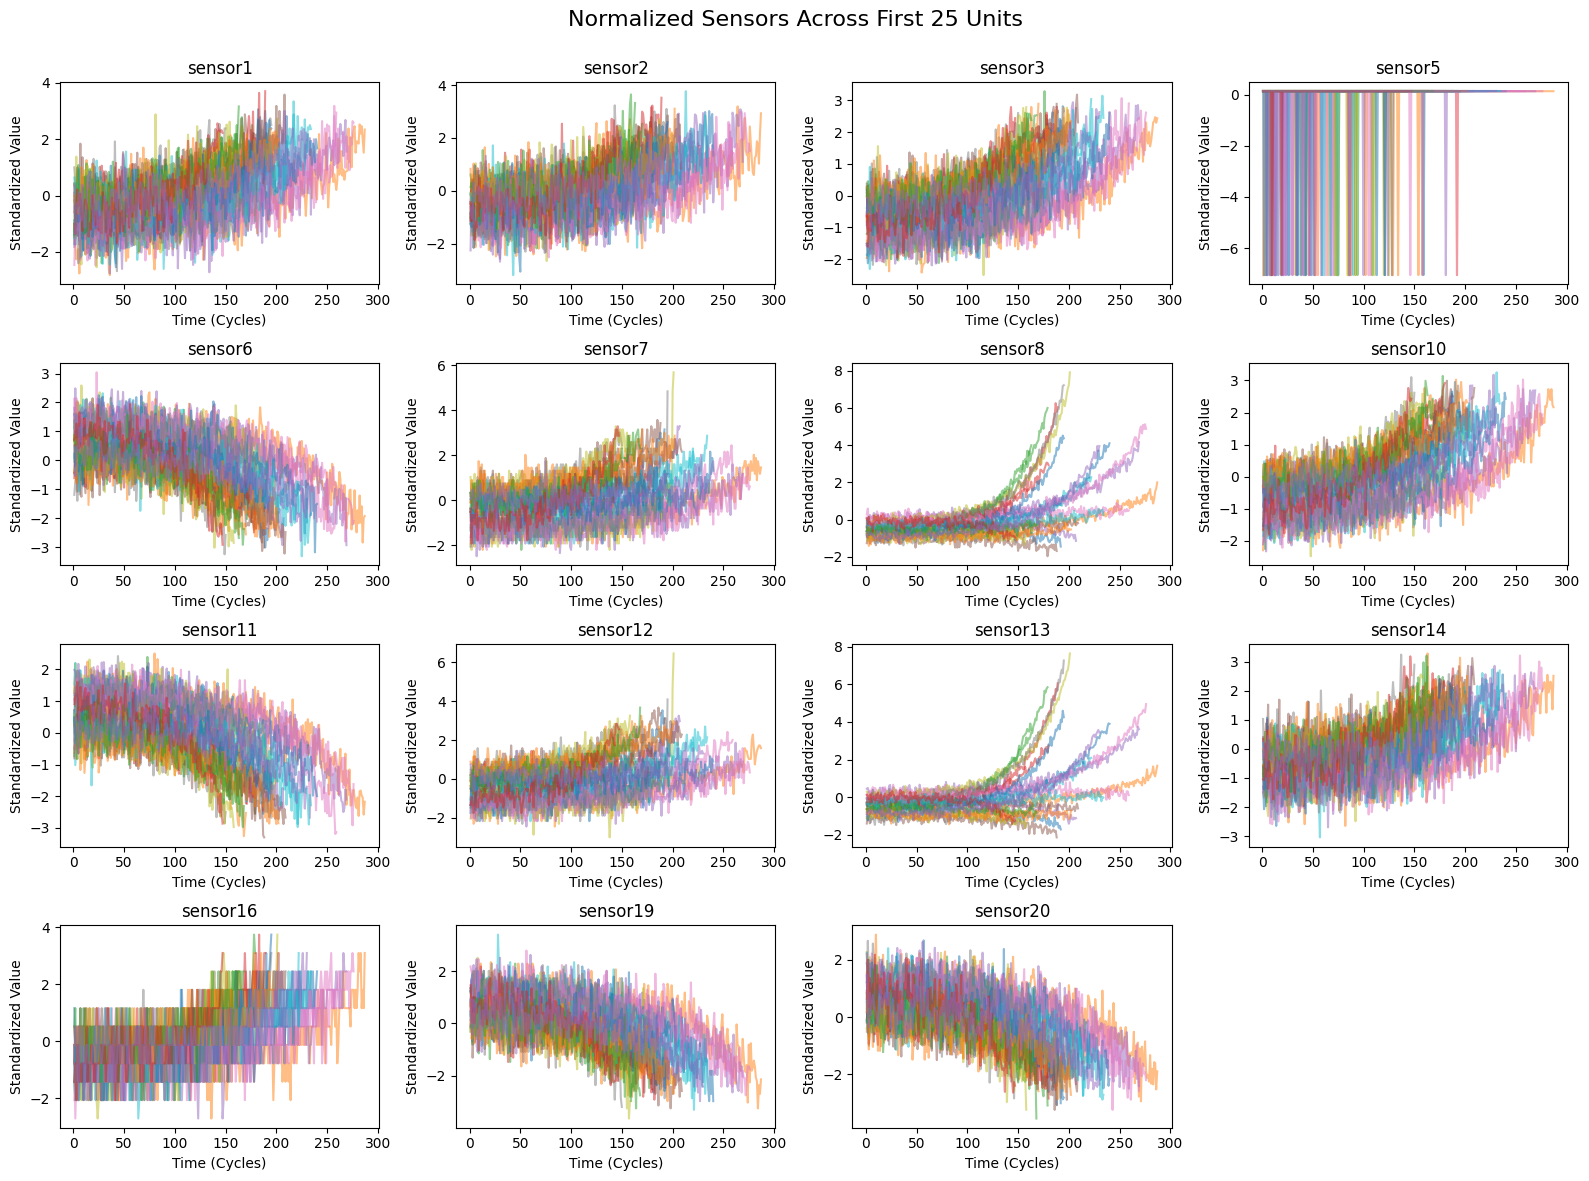

In [9]:
# Plot the normalized input data for all units and a single unit
import math

# Dynamically find the remaining sensor columns
sensor_cols = [col for col in data_train_scaled.columns if 'sensor' in col]
num_sensors = len(sensor_cols)

# Calculate a clean grid size (4 columns wide)
cols = 4
rows = math.ceil(num_sensors / cols)

# Setup the plot
fig, axs = plt.subplots(rows, cols, figsize=(16, 3 * rows))
fig.suptitle('Normalized Sensors Across First 25 Units', fontsize=16)
axs = axs.flatten()

# Loop through remaining sensors and plot the first 25 units
for i, sensor_name in enumerate(sensor_cols):
    for unit in range(1, 26):
        unit_data = data_train_scaled[data_train_scaled['unit'] == unit]
        axs[i].plot(unit_data['time'], unit_data[sensor_name], alpha=0.5)
        
    axs[i].set_title(sensor_name)
    axs[i].set_xlabel('Time (Cycles)')
    axs[i].set_ylabel('Standardized Value')

# Clean up any extra empty subplots
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

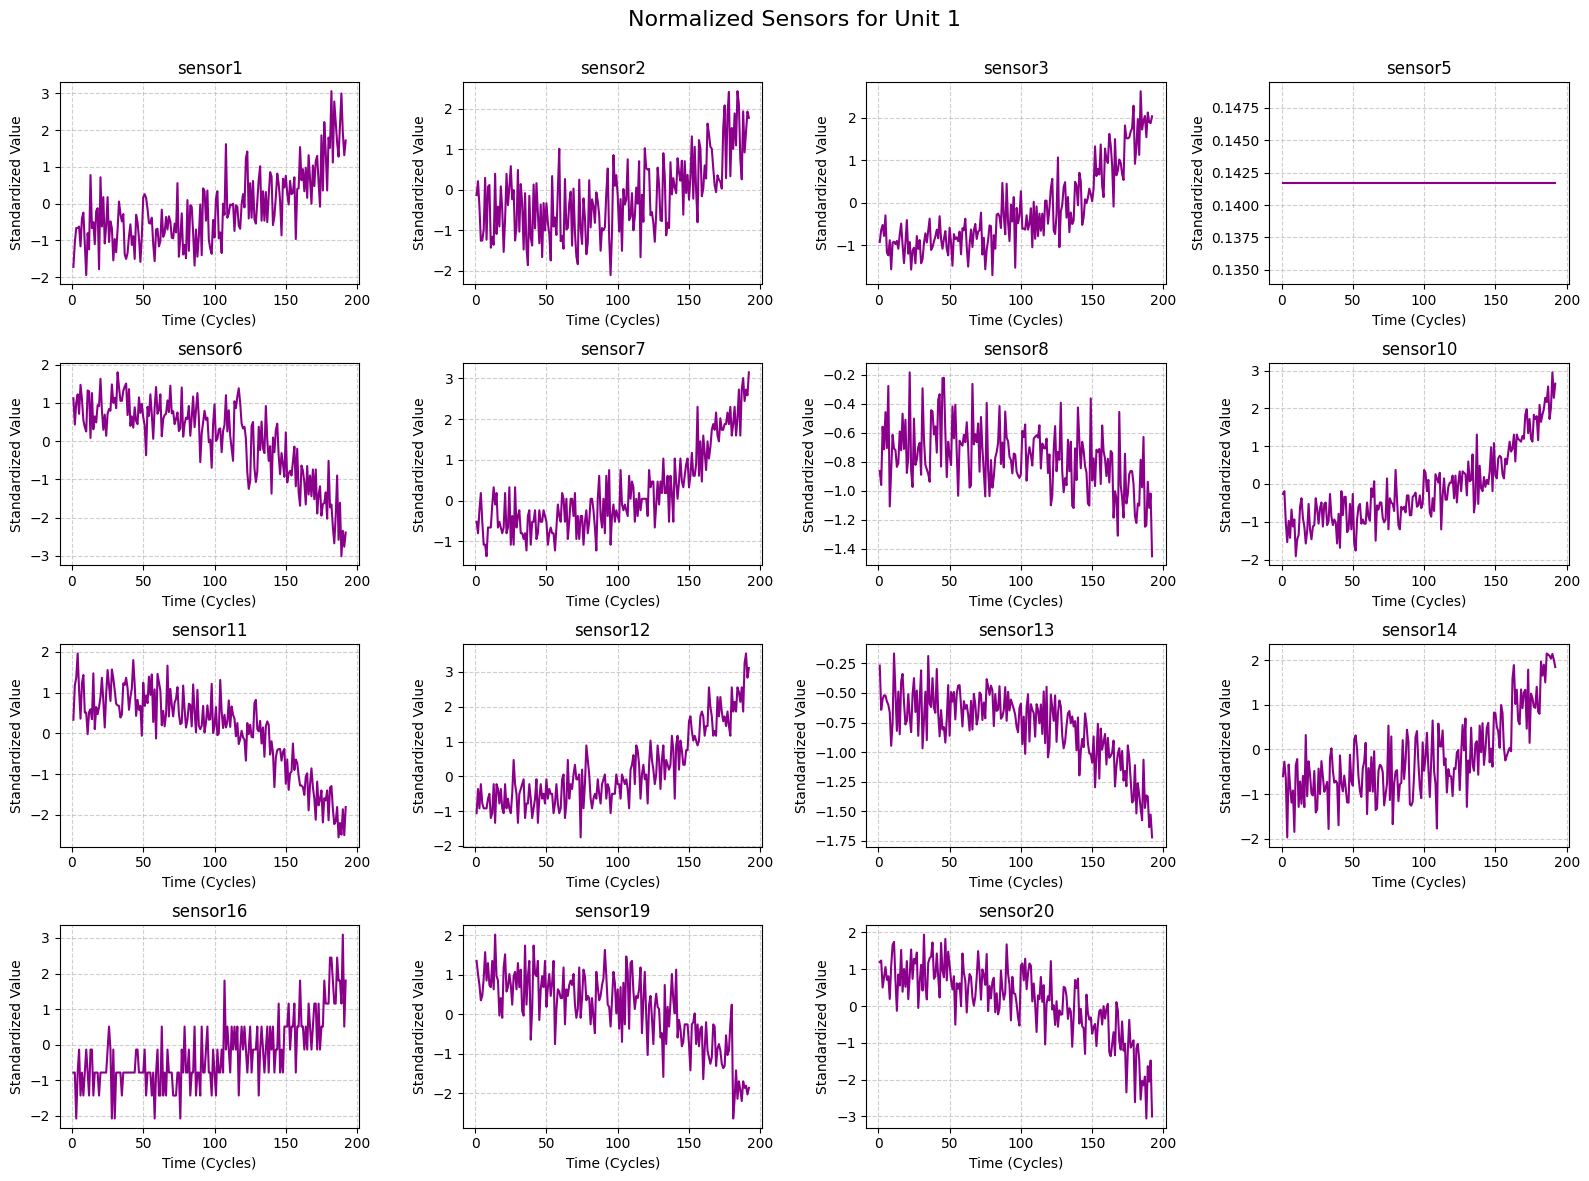

In [10]:
target_unit = 1
unit_data = data_train_scaled[data_train_scaled['unit'] == target_unit]

# Setup the plot
fig, axs = plt.subplots(rows, cols, figsize=(16, 3 * rows))
fig.suptitle(f'Normalized Sensors for Unit {target_unit}', fontsize=16)
axs = axs.flatten()

# Plot each remaining sensor for Unit 1
for i, sensor_name in enumerate(sensor_cols):
    axs[i].plot(unit_data['time'], unit_data[sensor_name], color='darkmagenta')
    axs[i].set_title(sensor_name)
    axs[i].set_xlabel('Time (Cycles)')
    axs[i].set_ylabel('Standardized Value')
    axs[i].grid(True, linestyle='--', alpha=0.6)

# Clean up empty subplots
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

## Prepare the training data and labels

In [11]:
# Create multivariate time series with length n_past and calculate the RUL for
# each training dataset.
# You don't have to touch this

trainX_all = []
trainY_all = []

n_past = 30

# Loop over units:
for i_unit in np.arange(1,101):

  data_unit = data_train_scaled[data_train["unit"]==i_unit]

  max_time_unit = np.max(data_unit["time"])

  # Loop over times (cycles). We start at i_time=n_past because the window is n_past long:
  for i_time in np.arange(n_past, max_time_unit):
    X = data_unit.iloc[i_time-n_past:i_time][name_list[2:]]
    Y = max_time_unit - data_unit.iloc[i_time]["time"]

    trainX_all.append(X)
    trainY_all.append(Y)

  print(i_unit, end=" ")

trainX_all = np.array(trainX_all)
trainY_all = np.array(trainY_all)

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 

Describe the loop above:

An RNN looks at a sequence of events to understand trends in the data.
The loop creates a window of 30 cycles (n_past = 30).
It places this window at the beginning of an engine's life, takes a snapshot of the sensors inside that window, and calculates how many cycles are left before the engine dies. Then, it slides the window forward by exactly one cycle, takes another snapshot, and repeats.

The outermost loop is going iver every engine unit.
Before the inner loop, the data of the current engine gets isolated and finds the las engine cycle before it broke.

The inner loop slides over time. It starts at cycle n_past=30 because that is the first time the RNN can make predictions.
Inside of it X grabs a chunk of rows according to the length of n_past.
Y is calculating the target label by extracting the remaining time the engine still works.
At the end of the loops the lists get turned into numpy arrays.

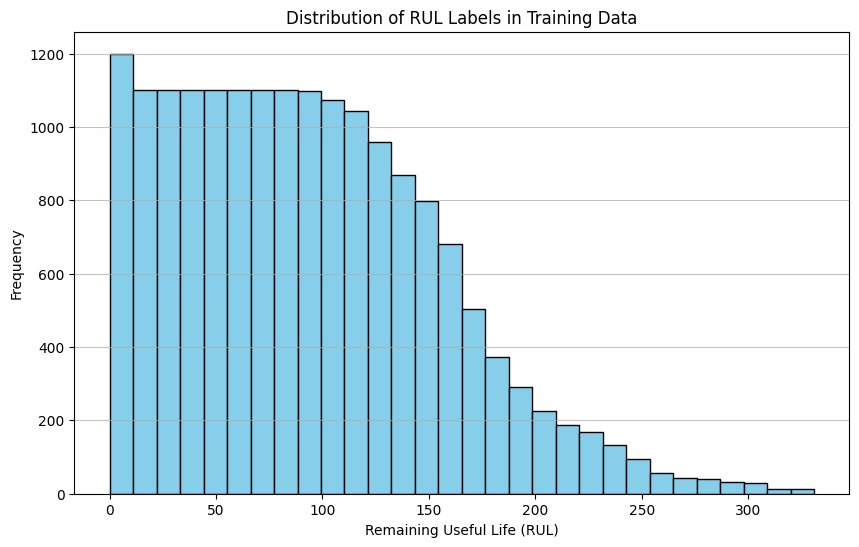

In [12]:
# Plot the labels of the training data set
plt.figure(figsize=(10, 6))
plt.hist(trainY_all, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of RUL Labels in Training Data')
plt.xlabel('Remaining Useful Life (RUL)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Split the data into training and validation

In [13]:
# Split the data into a training and validation dataset (we will load a seperate test dataset later)
# Hint: Consider shuffling the data

X_train, X_val, y_train, y_val = train_test_split(
    trainX_all, 
    trainY_all, 
    test_size=0.20, 
    random_state=42,
    shuffle=True
)

## Define the RNN

In [14]:
# Define the LSTM architecture

last_layer = 1

model = models.Sequential()

model.add(layers.LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))

model.add(layers.LSTM(units=50, return_sequences=False))

model.add(layers.Dense(last_layer))

model.compile(optimizer='adam', loss='mse')
model.summary()

/opt/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        13,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,451 (130.67 KB)

 Trainable params: 33,451 (130.67 KB)

 Non-trainable params: 0 (0.00 B)

## Train the RNN

In [15]:
# Define callbacks to save the best model during the training

# Options for EarlyStopping, ReduceLROnPlateau and ModelCheckpoint
#keras.callbacks.ReduceLROnPlateau(factor=, patience=, verbose=, min_lr=),
#keras.callbacks.EarlyStopping(patience=, verbose=)
#keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True, monitor=, mode=)
os.makedirs("models", exist_ok=True)


# ReduceLROnPlateau: If the model gets stuck, shrink the learning rate
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', # Watch the validation error
    factor=0.2,         # If stuck, drop the learning rate to 20% of its current value
    patience=5,         # Wait 5 epochs without improvement before dropping
    verbose=1, 
    min_lr=1e-5         # Don't let the learning rate get smaller than this
)

# EarlyStopping: If the model is clearly overfitting, kill the training early
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=10,        # Wait 10 epochs without improvement before stopping entirely
    verbose=1,
    restore_best_weights=True # Automatically reload the best weights when stopping
)

# ModelCheckpoint: Save the absolute best version of the model to your disk
model_checkpoint = callbacks.ModelCheckpoint(
    filepath="models/best_model.keras", # Save inside the folder you just made
    save_best_only=True, 
    monitor='val_loss', 
    mode='min',         # We want the 'minimum' error
    verbose=1
)

# Combine them into a list
my_callbacks = [reduce_lr, early_stop, model_checkpoint]

# Train the model!
results = model.fit(
    X_train, y_train,
    epochs=100,         # Set this high; EarlyStopping will stop it long before 100
    batch_size=64,      # 32 or 64 are perfect batch sizes for this dataset
    verbose=1,
    validation_data=(X_val, y_val),
    callbacks=my_callbacks
)

Epoch 1/100


2026-06-18 19:38:52.161425: I external/local_xla/xla/service/service.cc:163] XLA service 0x7031dc033530 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-06-18 19:38:52.161436: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
2026-06-18 19:38:52.188238: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


 16/221 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 13044.0163

I0000 00:00:1781811532.551128   27644 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 11111.4673
Epoch 1: val_loss improved from None to 9042.65918, saving model to models/best_model.keras

Epoch 1: finished saving model to models/best_model.keras
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 10325.3379 - val_loss: 9042.6592 - learning_rate: 0.0010
Epoch 2/100
219/221 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8701.1147
Epoch 2: val_loss improved from 9042.65918 to 7562.33008, saving model to models/best_model.keras

Epoch 2: finished saving model to models/best_model.keras
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 8436.9873 - val_loss: 7562.3301 - learning_rate: 0.0010
Epoch 3/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7404.4000
Epoch 3: val_loss improved from 7562.33008 to 6297.97070, saving model to models/best_model.keras

Epoch 3: finished saving model to models/best_model.keras
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 7067.2974 - val_loss: 6297.9707 - learning_rate: 0.0010
Epoch 4/100

## Plot the results and Evaluate the performance

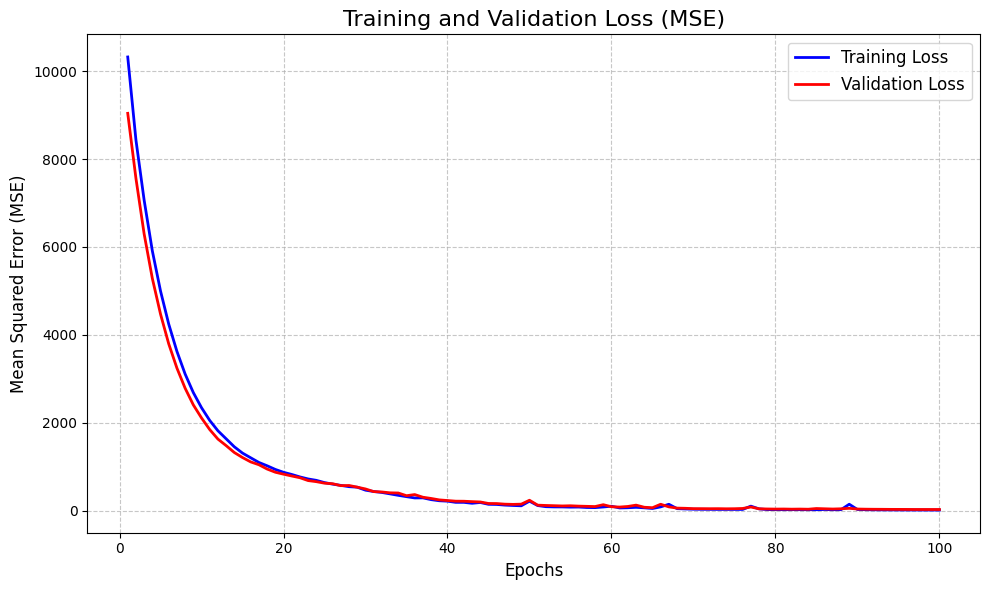

In [16]:
# Plotting training loss and validation loss
# Extract the loss values from the training history
loss = results.history['loss']
val_loss = results.history['val_loss']

# Create a list of epoch numbers for the x-axis
epochs = range(1, len(loss) + 1)

# Set up the plot
plt.figure(figsize=(10, 6))
plt.title('Training and Validation Loss (MSE)', fontsize=16)

# Plot both lines
plt.plot(epochs, loss, 'b-', label='Training Loss', linewidth=2)
plt.plot(epochs, val_loss, 'r-', label='Validation Loss', linewidth=2)

plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

The loss curve shows a healthy training process for the model. Training and validation loss are basically equal and converge at the end of the training.
The small spikes may be a result of the variable learning rate.


Best weights successfully loaded!
Generating predictions for training data...
441/441 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Generating predictions for validation data...
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


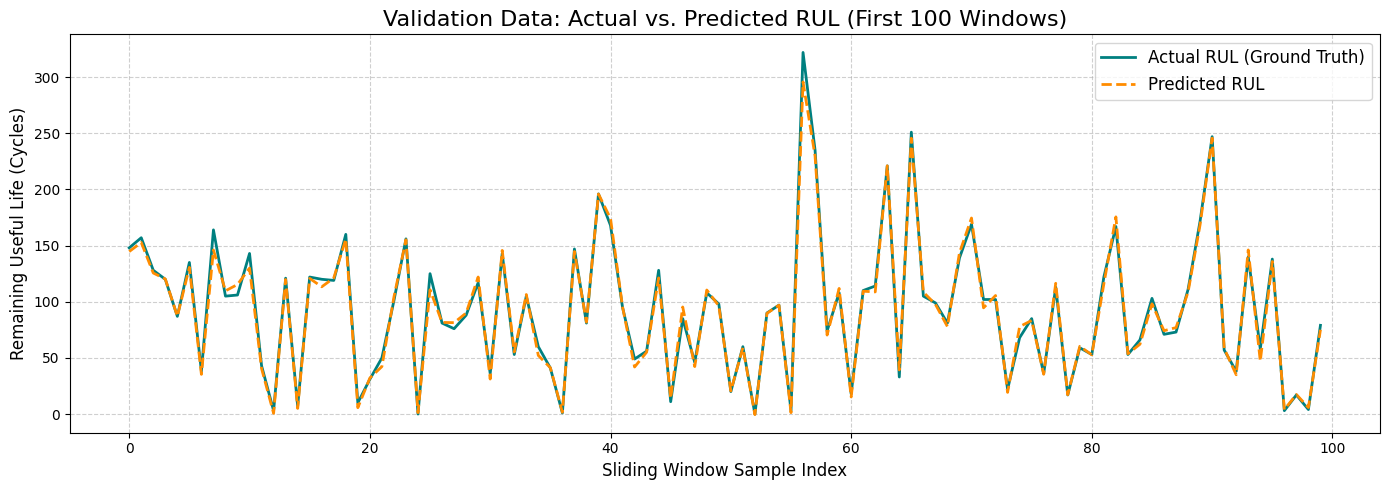

In [17]:
# Predict on the training dataset
model.load_weights("models/best_model.keras")
print("Best weights successfully loaded!")

# Predict on the training dataset
print("Generating predictions for training data...")
y_pred_train = model.predict(X_train)

# predict on the validation set to see how it handles data it wasn't directly trained on
print("Generating predictions for validation data...")
y_pred_val = model.predict(X_val)

# Flatten the predictions from a 2D array (N, 1) to a 1D array (N,) for easier plotting
y_pred_train = y_pred_train.flatten()
y_pred_val = y_pred_val.flatten()


plt.figure(figsize=(14, 5))
plt.plot(y_val[:100], label='Actual RUL (Ground Truth)', color='teal', linewidth=2)
plt.plot(y_pred_val[:100], label='Predicted RUL', color='darkorange', linestyle='dashed', linewidth=2)

plt.title('Validation Data: Actual vs. Predicted RUL (First 100 Windows)', fontsize=16)
plt.xlabel('Sliding Window Sample Index', fontsize=12)
plt.ylabel('Remaining Useful Life (Cycles)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

The predictions for all positions of the sliding window match the ground truth, or are at the very least exztremely close to it on the validation dataset.
The model can accurately predict the RUL for a random, isolated 30-cycle snapshot from any engine at any point of its life.

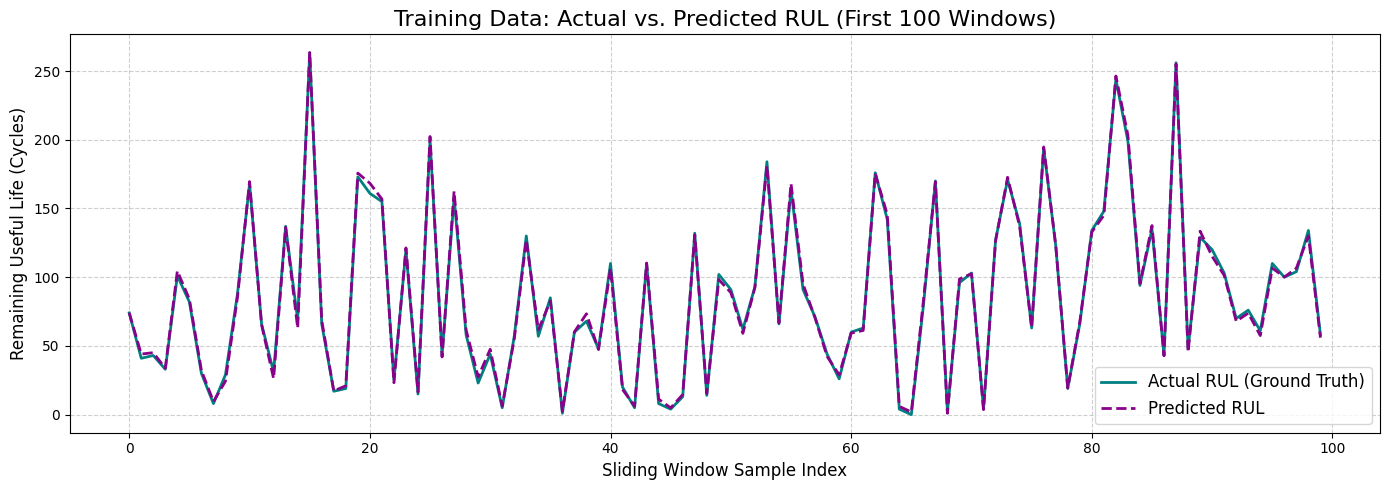

In [18]:
# Plot the true RUL and the network prediction for the training data
plt.figure(figsize=(14, 5))
plt.plot(y_train[:100], label='Actual RUL (Ground Truth)', color='teal', linewidth=2)
plt.plot(y_pred_train[:100], label='Predicted RUL', color='darkmagenta', linestyle='dashed', linewidth=2)

plt.title('Training Data: Actual vs. Predicted RUL (First 100 Windows)', fontsize=16)
plt.xlabel('Sliding Window Sample Index', fontsize=12)
plt.ylabel('Remaining Useful Life (Cycles)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Evaluate on the test data:

We load the test data and labels from two different files, `test_FD001.txt` and `RUL_FD001.txt`, which contain data for 100 engines (different from the training data). The test data is formatted sligthly differently from the training data. Instead of gettting full sequences from start of an engines life to its failure, we get shorter sequences of varying length for the 100 engines. The file `RUL_FD001.txt` then contains the time from the end of the sequence to the engine's failure, i.e., the RUL. In the code below we create 100 test datasets by cutting the test squences to the n_past last datapoints.

You should drop the same coloumns as with the training data and implement the same normalization.

In [19]:
import pandas as pd
import numpy as np


data_test = pd.read_csv('CMAPSSData/test_FD001.txt', delimiter='\s+', header=None, usecols=range(26))
labels_test = pd.read_csv('CMAPSSData/RUL_FD001.txt', delimiter='\s+', header=None, usecols=[0])

# Rebuild the original 26-column name list to assign to the raw test data
original_name_list = ['unit', 'time', 'setting0', 'setting1', 'setting2']
for i in range(21):
    original_name_list.append('sensor'+str(i))

data_test.columns = original_name_list
labels_test.columns = ['RUL']


data_test = data_test.drop(cols_to_drop, axis=1)

# Safely resync the name_list so it only contains the surviving columns
name_list = data_test.columns.tolist()

data_test_scaled = data_test.copy()
cols_to_normalize = data_test_scaled.columns.difference(['unit', 'time'])

# Scale using the exact ratios learned during training
data_test_scaled[cols_to_normalize] = scaler.transform(data_test_scaled[cols_to_normalize])


testX = []
testY = []
n_past = 30 

# Loop over units:
for i_unit in np.arange(1, 101):
    data_unit = data_test_scaled[data_test_scaled["unit"] == i_unit]

    # Grab the last n_past (30) cycles for this engine
    X = data_unit.iloc[-n_past:][name_list[2:]]
    Y = labels_test.iloc[i_unit-1]["RUL"]

    testX.append(X)
    testY.append(Y)

print(f"Dropped columns (from training logic): {cols_to_drop}")
print("Test windows successfully created!")

testX = np.array(testX)
testY = np.array(testY)

print(f"Test Data Shape: X = {testX.shape}, Y = {testY.shape}")

Dropped columns (from training logic): ['sensor0', 'sensor4', 'sensor9', 'sensor15', 'sensor17', 'sensor18', 'setting0', 'setting1', 'setting2']
Test windows successfully created!
Test Data Shape: X = (100, 30, 15), Y = (100,)


<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_26781/2079285443.py:5: SyntaxWarning: invalid escape sequence '\s'
  data_test = pd.read_csv('CMAPSSData/test_FD001.txt', delimiter='\s+', header=None, usecols=range(26))
/tmp/ipykernel_26781/2079285443.py:6: SyntaxWarning: invalid escape sequence '\s'
  labels_test = pd.read_csv('CMAPSSData/RUL_FD001.txt', delimiter='\s+', header=None, usecols=[0])


Best weights successfully loaded!
Generating predictions on the test data...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
------------------------------
Final Test RMSE: 24.94 cycles
Final Test MAE:  18.09 cycles
------------------------------


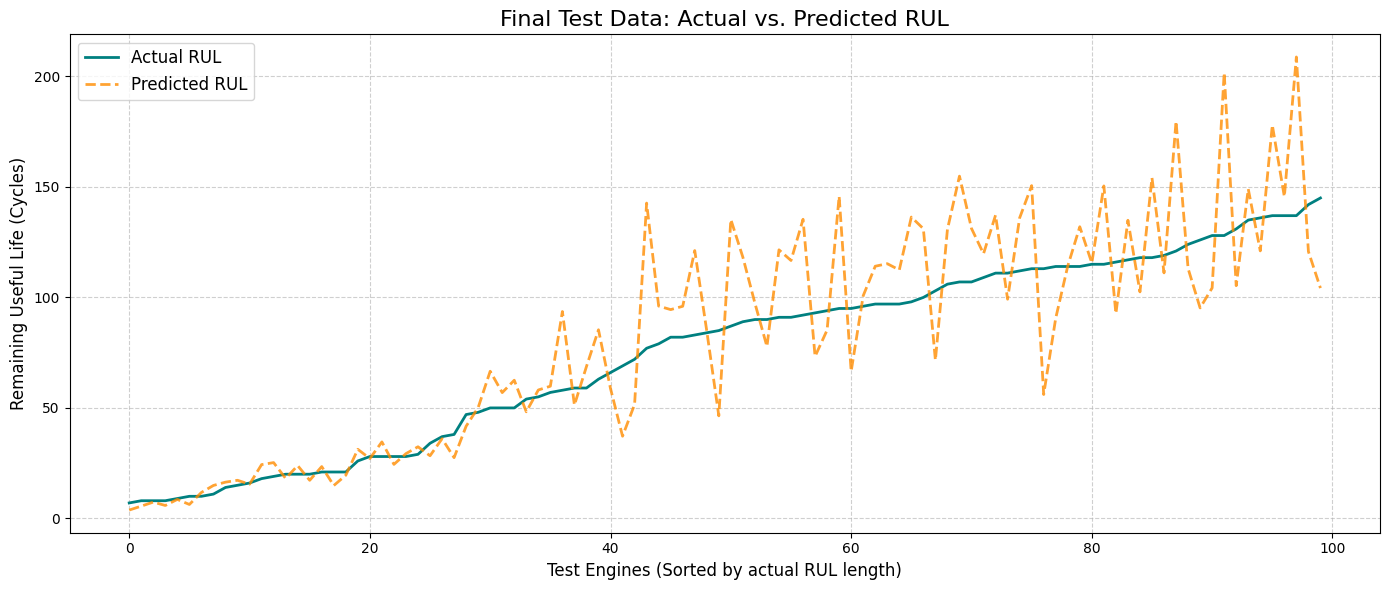

In [ ]:
# Plot the prediction and the true values for each test unit
# Hint: Depending on how you plot it, it may be easier to compare the true
# values and the predicted values if you order them in a smart way.
model.load_weights("models/best_model.keras")
print("Best weights successfully loaded!")


print("Generating predictions on the test data...")
y_pred_test = model.predict(testX)

# Flatten the predictions from 2D (100, 1) to 1D (100,)
y_pred_test = y_pred_test.flatten()

rmse = np.sqrt(mean_squared_error(testY, y_pred_test))
mae = mean_absolute_error(testY, y_pred_test)

print("-" * 30)
print(f"Final Test RMSE: {rmse:.2f} cycles")
print(f"Final Test MAE:  {mae:.2f} cycles")
print("-" * 30)

# 4. Visualize the Results
# We sort the values by the actual RUL before plotting. 
# This creates a smooth curve for the ground truth, making it much 
# easier to visually see where your model's predictions are jumping off track!
indices = np.argsort(testY)
sorted_testY = testY[indices]
sorted_predY = y_pred_test[indices]

plt.figure(figsize=(14, 6))
plt.plot(sorted_testY, label='Actual RUL', color='teal', linewidth=2)
plt.plot(sorted_predY, label='Predicted RUL', color='darkorange', alpha=0.8, linestyle='dashed', linewidth=2)

plt.title('Final Test Data: Actual vs. Predicted RUL', fontsize=16)
plt.xlabel('Test Engines (Sorted by actual RUL length)', fontsize=12)
plt.ylabel('Remaining Useful Life (Cycles)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

The model describes the RUL of engines less good on the test data, than it did on the validation data.
Nontheless, it learned the trends correctly. Especially for short RUL it is very accurate, while fluctuating more and more, the longer the RUL of an engine is.
This may be caused by the markers for failure looking like a healthy engine, when it has a long RUL left.

In [30]:
# Calculate the MSE and MAE of the training, validation and test predictions
mse_train = mean_squared_error(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)

# Calculate Validation Metrics
mse_val = mean_squared_error(y_val, y_pred_val)
mae_val = mean_absolute_error(y_val, y_pred_val)

# Calculate Test Metrics
mse_test = mean_squared_error(testY, y_pred_test)
mae_test = mean_absolute_error(testY, y_pred_test)


print("-" * 45)
print(f"{'Dataset Split':<15} | {'MSE':<12} | {'MAE':<12}")
print("-" * 45)
print(f"{'Training':<15} | {mse_train:<12.2f} | {mae_train:<12.2f}")
print(f"{'Validation':<15} | {mse_val:<12.2f} | {mae_val:<12.2f}")
print(f"{'Test':<15} | {mse_test:<12.2f} | {mae_test:<12.2f}")
print("-" * 45)

---------------------------------------------
Dataset Split   | MSE          | MAE         
---------------------------------------------
Training        | 10.57        | 2.39        
Validation      | 24.05        | 3.42        
Test            | 622.25       | 18.09       
---------------------------------------------


While the MSE is very high, this is mostly caused by wrongly estimating engines with a long RUL. If the model guesses 150 cycles left but in reality it is 200, the error of 50 is squared and results in an MSE of 2500 for that engine.

The MAE shows that the model works well for the test data as well. Maybe not as good as for the val and training data but still acceptable.

## (optional) Recommend Maintenance

----------------------------------------
Mean of Residuals:               -6.67 cycles
Standard Deviation of Residuals: 24.04 cycles
----------------------------------------


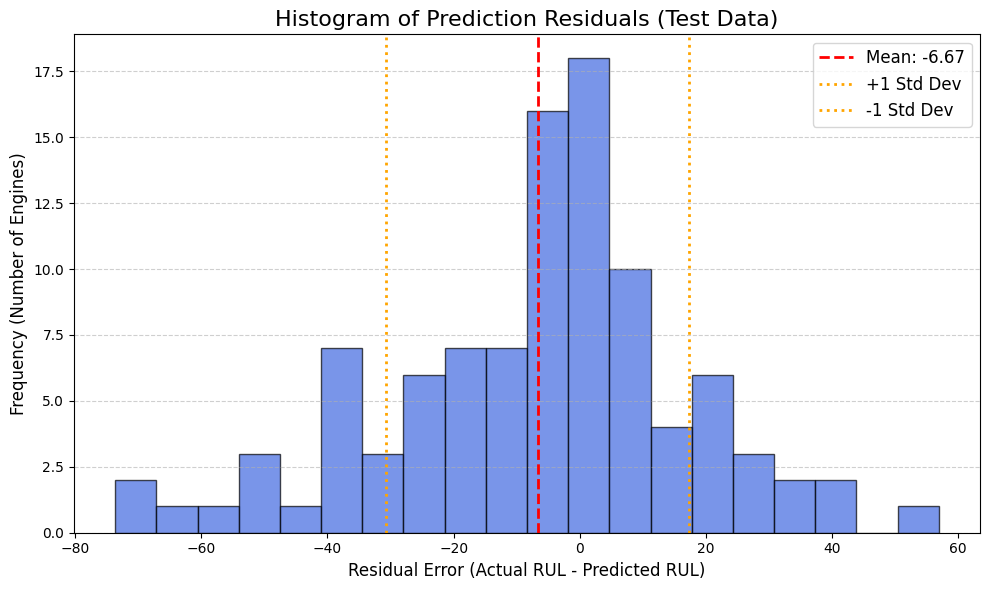

In [ ]:
# Plot the residuals in a histogram and determine the standard diviation
# A positive residual means the engine lived LONGER than predicted.
# A negative residual means the engine died SOONER than predicted.
residuals = testY - y_pred_test


std_dev_residuals = np.std(residuals)
mean_residual = np.mean(residuals)

print("-" * 40)
print(f"Mean of Residuals:               {mean_residual:.2f} cycles")
print(f"Standard Deviation of Residuals: {std_dev_residuals:.2f} cycles")
print("-" * 40)


plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=20, color='royalblue', edgecolor='black', alpha=0.7)

plt.axvline(mean_residual, color='red', linestyle='dashed', linewidth=2, 
            label=f'Mean: {mean_residual:.2f}')


plt.axvline(mean_residual + std_dev_residuals, color='orange', linestyle='dotted', linewidth=2, 
            label=f'+1 Std Dev')
plt.axvline(mean_residual - std_dev_residuals, color='orange', linestyle='dotted', linewidth=2, 
            label=f'-1 Std Dev')

plt.title('Histogram of Prediction Residuals (Test Data)', fontsize=16)
plt.xlabel('Residual Error (Actual RUL - Predicted RUL)', fontsize=12)
plt.ylabel('Frequency (Number of Engines)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

The model shows a bias towards overestimating how long engines will remain functional.
Much of this bias stems from the left tail of the distribution.
So sometimes the model vastly (up to and more than 60 cycles) overestimates how long the engines still work.

In [34]:
# Answer to question 6:
p5_residual = np.percentile(residuals, 5)

# Calculate the maintenance threshold
output_for_maint = 20 - p5_residual
print('The engine should be recomended for maintainance with an output below: ', output_for_maint, ' cycles of RUL')
print(f"5th Percentile of Residuals: {p5_residual:.2f} cycles")

The engine should be recomended for maintainance with an output below:  68.3928009033203  cycles of RUL
5th Percentile of Residuals: -48.39 cycles


This may seem high, but because its bias of overestimating how many cycles are left in the lifetime of an engine, and because we want to be REALLY sure it doesn't break in service, the margin of 68 cycles is reasonable.